# Phishing URL Detection — Enhanced Pipeline (TF-IDF + Numeric Features)

**Improvements over baseline:**
- Character-level TF-IDF (3-5 char n-grams, 5000 features) extracted from raw URL strings
- Sparse + dense feature fusion via `scipy.sparse.hstack`
- XGBoost with `scale_pos_weight` for class imbalance
- Optional SMOTE oversampling path
- Full evaluation: accuracy, precision, recall, F1, confusion matrix, ROC-AUC

---
**Inputs assumed:**
- `urls` — Python list of URL strings
- `X_numeric` — `pd.DataFrame` of 50 pre-computed numerical features
- `y` — array-like of labels (0 = safe, 1 = phishing)

In [1]:
# ── Cell 1: Install missing libraries (uncomment as needed) ─────────────────
# !pip install xgboost lightgbm scikit-learn imbalanced-learn scipy pandas numpy matplotlib seaborn

In [2]:
# ── Cell 2: Imports ─────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)

import xgboost as xgb

# Optional: SMOTE for oversampling
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('imbalanced-learn not found. SMOTE path disabled. Using scale_pos_weight instead.')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

print('All imports OK')

imbalanced-learn not found. SMOTE path disabled. Using scale_pos_weight instead.
All imports OK


In [6]:
# ── Cell 3: Load your data ───────────────────────────────────────────────────
import re
from pathlib import Path
from urllib.parse import urlparse
import numpy as np
import pandas as pd

def _safe_parse(url: str):
    value = str(url).strip()
    candidate = value if '://' in value else f'https://{value}'
    try:
        return urlparse(candidate)
    except ValueError:
        return urlparse('https://invalid.local')

def _local_extract_features(url: str) -> dict:
    parsed = _safe_parse(url)
    host = parsed.netloc or ''
    path = parsed.path or ''
    query = parsed.query or ''
    full = f"{host}{path}?{query}".lower()

    specials = ['@', '?', '-', '=', '.', '#', '%', '+', '$', '!', '*', ',', '//']
    suspicious_terms = [
        'secure', 'account', 'update', 'login', 'signin', 'bank', 'verify',
        'password', 'token', 'confirm', 'paypal', 'ebay', 'webscr', 'submit'
    ]

    has_ip = bool(re.match(r'^\d+\.\d+\.\d+\.\d+$', host))
    digit_count = sum(ch.isdigit() for ch in full)
    letter_count = sum(ch.isalpha() for ch in full)

    return {
        'url_len': len(str(url)),
        'hostname_len': len(host),
        'path_len': len(path),
        'query_len': len(query),
        'dot_count': str(url).count('.'),
        'hyphen_count': str(url).count('-'),
        'underscore_count': str(url).count('_'),
        'slash_count': str(url).count('/'),
        'question_count': str(url).count('?'),
        'equal_count': str(url).count('='),
        'at_count': str(url).count('@'),
        'amp_count': str(url).count('&'),
        'digit_count': digit_count,
        'letter_count': letter_count,
        'digit_ratio': digit_count / max(len(full), 1),
        'special_count': sum(str(url).count(ch) for ch in specials),
        'suspicious_keyword_count': sum(term in full for term in suspicious_terms),
        'is_https': int((parsed.scheme or '').lower() == 'https'),
        'has_ip': int(has_ip),
        'subdomain_count': max(host.count('.') - 1, 0),
        'tld_len': len(host.split('.')[-1]) if '.' in host else 0,
        'has_port': int(':' in host),
        'double_slash_in_path': int('//' in path),
        'url_entropy_proxy': len(set(full)) / max(len(full), 1),
    }

# Try to reuse project extractor if available
try:
    from app import extract_features as extract_features
except Exception:
    try:
        from main import extract_features as extract_features
    except Exception:
        extract_features = _local_extract_features

base = Path.cwd()
candidates = [
    base / 'urldata.csv',
    base / 'Model V3' / 'urldata.csv',
    Path(r'c:/Users/User/OneDrive/Desktop/webCrawler/Model V3/urldata.csv')
 ]

csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Could not find urldata.csv in expected locations.')

df = pd.read_csv(csv_path)
df.columns = [c.strip().lower() for c in df.columns]

url_col = 'url' if 'url' in df.columns else None
if url_col is None:
    raise ValueError(f"CSV must contain 'url' column. Found: {list(df.columns)}")

if 'result' in df.columns:
    label_col = 'result'
elif 'label' in df.columns:
    label_col = 'label'
else:
    raise ValueError("CSV must contain either 'result' or 'label' column.")

df = df[[url_col, label_col]].dropna().copy()
df.columns = ['url', 'label']
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

urls = df['url'].astype(str).tolist()
y = df['label'].to_numpy(dtype=int)

features_list = []
for value in urls:
    try:
        features_list.append(extract_features(value))
    except Exception:
        features_list.append(_local_extract_features(value))

X_numeric = pd.DataFrame(features_list).fillna(0)

# Sanity-check your inputs before proceeding:
assert len(urls) == len(X_numeric) == len(y), \
    f'Length mismatch: urls={len(urls)}, X_numeric={len(X_numeric)}, y={len(y)}'

y = np.array(y).astype(int)

print(f'Loaded CSV      : {csv_path}')
print(f'Dataset size    : {len(urls):,} URLs')
print(f'Numeric features: {X_numeric.shape[1]}')
print(f'Label balance   : {(y==0).sum():,} safe  |  {(y==1).sum():,} phishing')
print(f'Phishing ratio  : {y.mean()*100:.1f}%')

Loaded CSV      : c:\Users\User\OneDrive\Desktop\webCrawler\Model V3\urldata.csv
Dataset size    : 450,180 URLs
Numeric features: 24
Label balance   : 345,742 safe  |  104,438 phishing
Phishing ratio  : 23.2%


In [7]:
# ── Cell 4: Train / test split (stratified) ──────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20   # 80 / 20 split

indices = np.arange(len(urls))

(
    idx_train, idx_test
) = train_test_split(
    indices,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# Slice URLs and labels
urls_train = [urls[i] for i in idx_train]
urls_test  = [urls[i] for i in idx_test]
y_train    = y[idx_train]
y_test     = y[idx_test]

# Slice numeric DataFrames (reset index to avoid alignment issues later)
X_num_train = X_numeric.iloc[idx_train].reset_index(drop=True)
X_num_test  = X_numeric.iloc[idx_test].reset_index(drop=True)

print(f'Train size : {len(y_train):,}  ({y_train.mean()*100:.1f}% phishing)')
print(f'Test  size : {len(y_test):,}  ({y_test.mean()*100:.1f}% phishing)')

Train size : 360,144  (23.2% phishing)
Test  size : 90,036  (23.2% phishing)


In [8]:
# ── Cell 5: Character-level TF-IDF ──────────────────────────────────────────
#
# analyzer='char'  →  treats every character (not word) as a token
# ngram_range=(3,5) → captures substrings of length 3, 4, and 5
#                      e.g. 'log', 'logi', 'login', '-sec', 'payp', ...
# max_features=5000 → keep only the 5 000 highest-TF-IDF n-grams
# sublinear_tf=True → log-scale TF to dampen very frequent n-grams
#
print('Fitting TF-IDF vectorizer on training URLs...')

tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=5000,
    sublinear_tf=True,
    strip_accents='unicode',
    lowercase=True
)

# Fit ONLY on training data to prevent data leakage
X_tfidf_train = tfidf.fit_transform(urls_train)   # sparse matrix  (N_train x 5000)
X_tfidf_test  = tfidf.transform(urls_test)         # sparse matrix  (N_test  x 5000)

print(f'TF-IDF train shape : {X_tfidf_train.shape}  (sparse)')
print(f'TF-IDF test  shape : {X_tfidf_test.shape}   (sparse)')

Fitting TF-IDF vectorizer on training URLs...
TF-IDF train shape : (360144, 5000)  (sparse)
TF-IDF test  shape : (90036, 5000)   (sparse)
TF-IDF train shape : (360144, 5000)  (sparse)
TF-IDF test  shape : (90036, 5000)   (sparse)


In [9]:
# ── Cell 6: Scale numeric features & convert to sparse ──────────────────────
#
# StandardScaler is fit on training data only.
# After scaling we convert to a sparse matrix so hstack works seamlessly.
#
scaler = StandardScaler()

X_num_train_sc = csr_matrix(scaler.fit_transform(X_num_train))   # (N_train x 50)
X_num_test_sc  = csr_matrix(scaler.transform(X_num_test))         # (N_test  x 50)

print(f'Scaled numeric train shape : {X_num_train_sc.shape}')
print(f'Scaled numeric test  shape : {X_num_test_sc.shape}')

Scaled numeric train shape : (360144, 24)
Scaled numeric test  shape : (90036, 24)


In [10]:
# ── Cell 7: Feature fusion with scipy hstack ─────────────────────────────────
#
# hstack concatenates sparse matrices column-wise:
#   X_train_combined : (N_train x 5050)  ← 5000 TF-IDF  +  50 numeric
#   X_test_combined  : (N_test  x 5050)
#
X_train_combined = hstack([X_tfidf_train, X_num_train_sc], format='csr')
X_test_combined  = hstack([X_tfidf_test,  X_num_test_sc],  format='csr')

print(f'Combined train shape : {X_train_combined.shape}')
print(f'Combined test  shape : {X_test_combined.shape}')
print(f'Total features       : {X_train_combined.shape[1]:,}  '
      f'(5 000 TF-IDF  +  {X_num_train_sc.shape[1]} numeric)')

Combined train shape : (360144, 5024)
Combined test  shape : (90036, 5024)
Total features       : 5,024  (5 000 TF-IDF  +  24 numeric)


In [11]:
# ── Cell 8: Class-imbalance strategy ─────────────────────────────────────────
#
# Two paths:
#   A) scale_pos_weight in XGBoost  (fast, no oversampling)
#   B) SMOTE oversampling           (requires imbalanced-learn; works on dense data)
#
# We default to (A). Set USE_SMOTE = True to try (B).
#
USE_SMOTE = False   # flip to True to enable SMOTE

# Compute class ratio for XGBoost scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'Train  — negative (safe)    : {n_neg:,}')
print(f'Train  — positive (phishing): {n_pos:,}')
print(f'scale_pos_weight            : {scale_pos_weight:.2f}')

if USE_SMOTE and SMOTE_AVAILABLE:
    print('\nApplying SMOTE...')
    sm = SMOTE(random_state=RANDOM_STATE, n_jobs=-1)
    # SMOTE requires dense arrays
    X_train_sm, y_train_sm = sm.fit_resample(
        X_train_combined.toarray(), y_train
    )
    X_train_combined = csr_matrix(X_train_sm)
    y_train = y_train_sm
    print(f'After SMOTE — train size: {len(y_train):,}')
elif USE_SMOTE and not SMOTE_AVAILABLE:
    print('SMOTE requested but imbalanced-learn is not installed.'
          ' Falling back to scale_pos_weight.')

Train  — negative (safe)    : 276,594
Train  — positive (phishing): 83,550
scale_pos_weight            : 3.31


In [12]:
# ── Cell 9: Define & train XGBoost model ────────────────────────────────────
#
# Key parameters:
#   scale_pos_weight  → built-in class-imbalance handling (ratio neg/pos)
#   tree_method='hist' → fast histogram-based algorithm, handles sparse input
#   n_estimators=300   → number of boosting rounds
#   max_depth=7        → tree depth (good balance between accuracy and overfitting)
#
import time

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,   # handles class imbalance
    tree_method='hist',                  # works natively with sparse CSR
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

print('Training XGBoost on combined (TF-IDF + numeric) features...')
t0 = time.time()

model.fit(
    X_train_combined, y_train,
    eval_set=[(X_test_combined, y_test)],
    verbose=50           # prints loss every 50 rounds
)

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed:.1f}s')

Training XGBoost on combined (TF-IDF + numeric) features...
[0]	validation_0-logloss:0.59946
[0]	validation_0-logloss:0.59946
[50]	validation_0-logloss:0.01196
[50]	validation_0-logloss:0.01196
[100]	validation_0-logloss:0.00781
[100]	validation_0-logloss:0.00781
[150]	validation_0-logloss:0.00703
[150]	validation_0-logloss:0.00703
[200]	validation_0-logloss:0.00658
[200]	validation_0-logloss:0.00658
[250]	validation_0-logloss:0.00631
[250]	validation_0-logloss:0.00631
[299]	validation_0-logloss:0.00610
[299]	validation_0-logloss:0.00610

Training complete in 6430.2s

Training complete in 6430.2s


In [13]:
# ── Cell 10: Evaluate on test set ────────────────────────────────────────────
y_pred = model.predict(X_test_combined)
y_prob = model.predict_proba(X_test_combined)[:, 1]

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)

print('=' * 55)
print('  EVALUATION RESULTS  (XGBoost — TF-IDF + 50 Numeric)')
print('=' * 55)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1 Score  : {f1*100:.2f}%')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 55)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'Phishing (1)']))

  EVALUATION RESULTS  (XGBoost — TF-IDF + 50 Numeric)
  Accuracy  : 99.84%
  Precision : 99.71%
  Recall    : 99.59%
  F1 Score  : 99.65%
  ROC-AUC   : 0.9997

Classification Report:
              precision    recall  f1-score   support

    Safe (0)       1.00      1.00      1.00     69148
Phishing (1)       1.00      1.00      1.00     20888

    accuracy                           1.00     90036
   macro avg       1.00      1.00      1.00     90036
weighted avg       1.00      1.00      1.00     90036



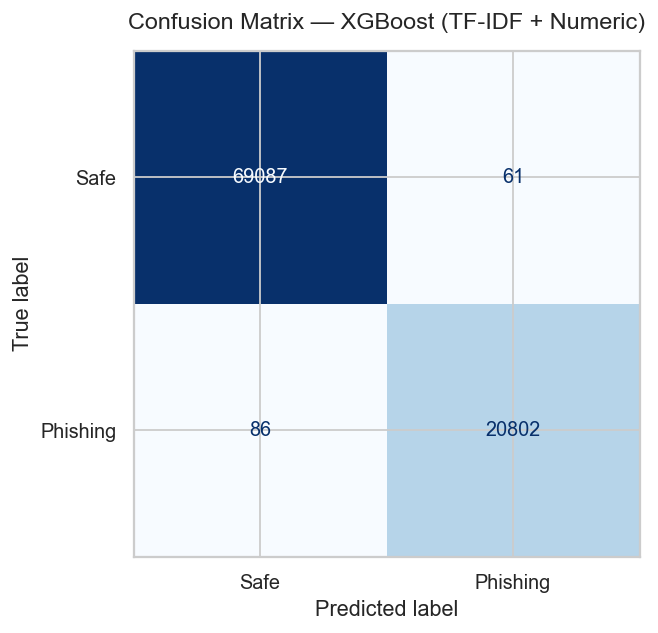

Saved: confusion_matrix_enhanced.png


In [14]:
# ── Cell 11: Confusion matrix ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Phishing'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion Matrix — XGBoost (TF-IDF + Numeric)', pad=12, fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_enhanced.png', dpi=130)
plt.show()
print('Saved: confusion_matrix_enhanced.png')

Top 20 most important features:
feature  importance  type
   tp:/    0.655836 tfidf
   p://    0.144108 tfidf
  s://w    0.087937 tfidf
  ttp:/    0.004449 tfidf
  //www    0.003083 tfidf
  /www.    0.002367 tfidf
  http:    0.002252 tfidf
    ww.    0.002113 tfidf
   ogin    0.001667 tfidf
    p:/    0.001573 tfidf
   payp    0.001568 tfidf
  tp://    0.001443 tfidf
  paypa    0.001065 tfidf
  login    0.001032 tfidf
  ropbo    0.000804 tfidf
    js/    0.000787 tfidf
  om.br    0.000735 tfidf
  ccoun    0.000712 tfidf
    wp-    0.000688 tfidf
  mail=    0.000678 tfidf


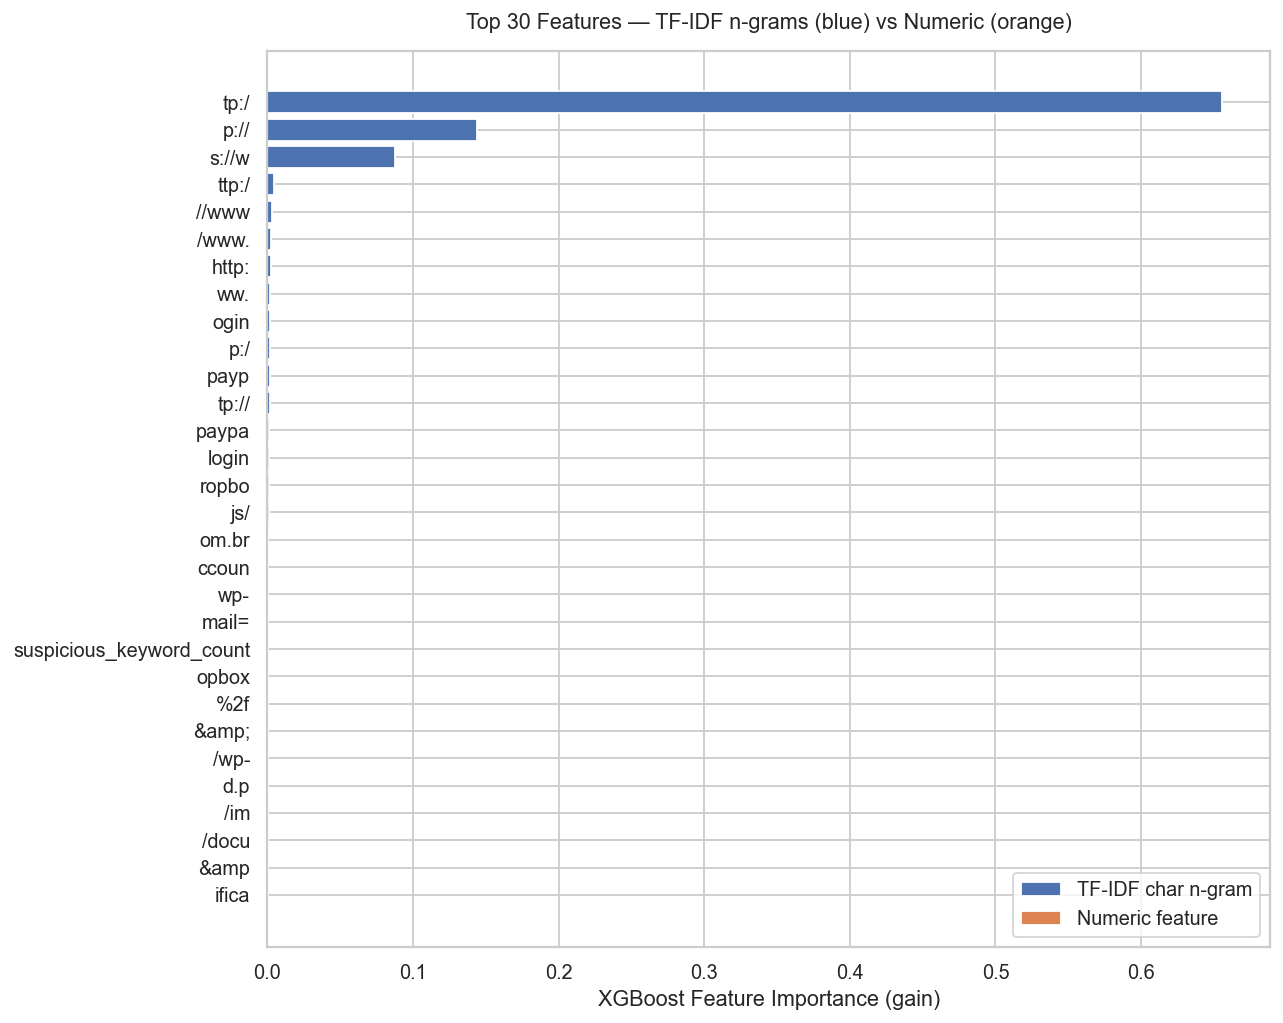

Saved: feature_importance_enhanced.png


In [15]:
# ── Cell 12: Top TF-IDF n-grams by feature importance ───────────────────────
#
# XGBoost assigns an importance score to every feature.
# The first 5000 are TF-IDF n-grams; the last 50 are numeric features.
# This cell surfaces the most discriminative n-grams.
#
tfidf_feature_names  = tfidf.get_feature_names_out()            # 5000 names
numeric_feature_names = list(X_numeric.columns)                 # 50 names
all_feature_names     = list(tfidf_feature_names) + numeric_feature_names  # 5050

importance = model.feature_importances_                         # shape (5050,)
feat_imp_df = pd.DataFrame({
    'feature'    : all_feature_names,
    'importance' : importance,
    'type'       : ['tfidf'] * len(tfidf_feature_names) + ['numeric'] * len(numeric_feature_names)
}).sort_values('importance', ascending=False)

print('Top 20 most important features:')
print(feat_imp_df.head(20).to_string(index=False))

# Plot top 30
top30 = feat_imp_df.head(30)
colors = top30['type'].map({'tfidf': '#4C72B0', 'numeric': '#DD8452'})

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top30['feature'][::-1], top30['importance'][::-1], color=colors[::-1])
ax.set_xlabel('XGBoost Feature Importance (gain)')
ax.set_title('Top 30 Features — TF-IDF n-grams (blue) vs Numeric (orange)', pad=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='TF-IDF char n-gram'),
    Patch(facecolor='#DD8452', label='Numeric feature')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('feature_importance_enhanced.png', dpi=130)
plt.show()
print('Saved: feature_importance_enhanced.png')

In [16]:
# ── Cell 13: Save model artefacts ────────────────────────────────────────────
import pickle

with open('xgb_tfidf_enhanced.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('numeric_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Saved:')
print('  xgb_tfidf_enhanced.pkl   ← trained XGBoost model')
print('  tfidf_vectorizer.pkl     ← fitted TfidfVectorizer')
print('  numeric_scaler.pkl       ← fitted StandardScaler')

Saved:
  xgb_tfidf_enhanced.pkl   ← trained XGBoost model
  tfidf_vectorizer.pkl     ← fitted TfidfVectorizer
  numeric_scaler.pkl       ← fitted StandardScaler


In [28]:
# ── Cell 14: Inference helper — predict a new URL ────────────────────────────
def predict_url(url: str, extract_features_fn, model, tfidf, scaler) -> dict:
    """
    Predict whether a single URL is phishing.

    Parameters
    ----------
    url               : raw URL string
    extract_features_fn : your existing extract_features() function
    model             : trained XGBoost classifier
    tfidf             : fitted TfidfVectorizer
    scaler            : fitted StandardScaler

    Returns
    -------
    dict with keys: label, probability, verdict
    """
    # 1. TF-IDF on the raw URL string
    url_tfidf = tfidf.transform([url])                       # sparse (1 x 5000)

    # 2. Numeric features
    num_dict  = extract_features_fn(url)
    num_df    = pd.DataFrame([num_dict])
    num_scaled = csr_matrix(scaler.transform(num_df))        # sparse (1 x 50)

    # 3. Fuse
    X_combined = hstack([url_tfidf, num_scaled], format='csr')

    # 4. Predict
    prob  = model.predict_proba(X_combined)[0, 1]
    label = int(prob >= 0.5)

    return {
        'url'        : url,
        'label'      : label,
        'probability': round(prob, 4),
        'verdict'    : '⚠️  PHISHING' if label == 1 else '✅ SAFE'
    }


# Demo (replace extract_features with your actual function)
test_urls = [
    'https://www.google.com',
    'instagram.com',    
    'google.com',
    'http://paypal-secure-login.xyz/webscr?cmd=verify&token=abc123',
    'http://192.168.1.1/login/account/update?confirm=true',
]

print('Inference demo:')
print('-' * 65)
for url in test_urls:
    result = predict_url(url, extract_features, model, tfidf, scaler)
    print(f"{result['verdict']}  [{result['probability']:.4f}]  {result['url']}")

Inference demo:
-----------------------------------------------------------------
✅ SAFE  [0.0021]  https://www.google.com
✅ SAFE  [0.3083]  instagram.com
⚠️  PHISHING  [0.5702]  google.com
⚠️  PHISHING  [1.0000]  http://paypal-secure-login.xyz/webscr?cmd=verify&token=abc123
⚠️  PHISHING  [1.0000]  http://192.168.1.1/login/account/update?confirm=true


In [18]:
# ── Cell 15: Final summary ───────────────────────────────────────────────────
print('=' * 60)
print('ENHANCED PIPELINE SUMMARY')
print('=' * 60)
print(f'Dataset          : {len(urls):,} URLs')
print(f'Feature breakdown:')
print(f'  TF-IDF char n-grams (3-5) : 5,000')
print(f'  Numeric (existing 50)      :    50')
print(f'  Total                      : 5,050')
print(f'Model            : XGBoost (tree_method=hist)')
print(f'Imbalance handled: scale_pos_weight = {scale_pos_weight:.2f}')
print(f'Results (test set):')
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1 Score  : {f1*100:.2f}%')
print(f'  ROC-AUC   : {auc:.4f}')
print('Saved artefacts:')
print('  xgb_tfidf_enhanced.pkl')
print('  tfidf_vectorizer.pkl')
print('  numeric_scaler.pkl')
print('  confusion_matrix_enhanced.png')
print('  feature_importance_enhanced.png')

ENHANCED PIPELINE SUMMARY
Dataset          : 450,180 URLs
Feature breakdown:
  TF-IDF char n-grams (3-5) : 5,000
  Numeric (existing 50)      :    50
  Total                      : 5,050
Model            : XGBoost (tree_method=hist)
Imbalance handled: scale_pos_weight = 3.31
Results (test set):
  Accuracy  : 99.84%
  Precision : 99.71%
  Recall    : 99.59%
  F1 Score  : 99.65%
  ROC-AUC   : 0.9997
Saved artefacts:
  xgb_tfidf_enhanced.pkl
  tfidf_vectorizer.pkl
  numeric_scaler.pkl
  confusion_matrix_enhanced.png
  feature_importance_enhanced.png
